In [286]:
from samalg import SAM
import scanpy as sc
import statistics
import matplotlib.pyplot as plt
import seaborn as sns
import random
import pandas as pd
import matplotlib.colors
import scipy
import numpy as np
import sklearn.metrics as metrics
from scipy import sparse
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import time
import pickle

In [287]:
fn_NN = 'Active_SAM_joined/SAM_XT_nonneural_cleaned_07212026.h5ad'
sam_NN = SAM()
sam_NN.load_data(fn_NN)

In [288]:
fn = 'Active_SAM_joined/SAM_XT_joined_Slc17a6_cleaned_03122205.h5ad'
sam = SAM()
sam.load_data(fn)

In [289]:
sam.adata.obs.columns

Index(['n_genes', 'n_counts', 'key', 'leiden_clusters', 'eq_subclass',
       'eq_subclass_lc', 'eq_subclass_frac', 'eq_subclass_nounlabeled',
       'eq_subclass_nounlabeled_NN', 'eq_subclass_nounlabeled_nnm',
       'eq_subclass_nounlabeled_nmm', 'neurotransmitter',
       'ss_subclass_nounlabeled', 'ss_subclass_v2_nounlabeled',
       'ss_subclass_v3_nounlabeled', 'ss_subclass_nounlabeled_nmm',
       'ss_subclass', 'ss_subclass_nounlabeled_nmm_micro',
       'ss_subclass_nounlabeled_nmm_v2', 'ss_subclass_nounlabeled_nmm_v2_nn',
       'ss_subclass_nounlabeled_nmm_v3_nn', 'neurotransmitter_v2', 'test',
       'ss_subclass_old', 'ss_subclass_v4_nounlabeled',
       'ss_subclass_v4_nounlabeled_nn'],
      dtype='object')

In [290]:
sm = load_samap('Active_SAMap_Joined/sm_hypo_nonneural_07222026.pkl')

In [291]:
org_one = 'mg'
org_two = 'xt'

In [292]:
sm.sams[org_two].clustering(param = 2)

In [293]:
level_one = 'subclass_id_label'
level_two = 'leiden_clusters'

In [294]:
keys = {org_one:level_one,org_two:level_two}
D,MappingTable = get_mapping_scores(sm,keys)

lim_MappingTable =  MappingTable.loc[:,[i for i in MappingTable.columns if i[:2] == org_one]]
lim_MappingTable = lim_MappingTable.loc[[i for i in lim_MappingTable.index if i[:2] == org_two],:]

/scratch/miniconda/lib/python3.7/site-packages/samap/analysis.py:1609: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  samap.adata.obs[l] = pd.Categorical(cl)


In [295]:
df = pd.read_csv('Vert_emapper_allorgs_07032026.tsv',delimiter='\t', index_col = 'Unnamed: 0')

In [296]:
df.loc[df.index[np.where(df['MM'] == 'Gfap')],:]

,MM,MO,CJ,AC,XT,DR
49511@7742,Gfap,Gfap,GFAP,gfap,NaN,gfap


In [297]:
new_mapping = {}
for item in lim_MappingTable.index:
    if np.max(lim_MappingTable.loc[item,:]) > .2 and len(sm.sams[org_two].adata[sm.sams[org_two].adata.obs[level_two] == int(item[3:])]) > 25:
        new_mapping[item] = lim_MappingTable.loc[item,:].idxmax()[3:]
        if np.max(lim_MappingTable.loc[item,:])/lim_MappingTable.loc[item,:].nlargest(2).iloc[-1] < 2 and np.max(lim_MappingTable.loc[item,:]) - lim_MappingTable.loc[item,:].nlargest(2).iloc[-1] < 0.2:
            print(item,lim_MappingTable.loc[item,:].idxmax())
    else:
        print('Unmapped ' + item, len(sm.sams[org_two].adata[sm.sams[org_two].adata.obs['leiden_clusters'] == int(item[3:])]))

xt_13 mg_334 Microglia NN
Unmapped xt_18 35
xt_3 mg_319 Astro-TE NN
xt_5 mg_319 Astro-TE NN
Unmapped xt_6 161
Unmapped xt_7 153


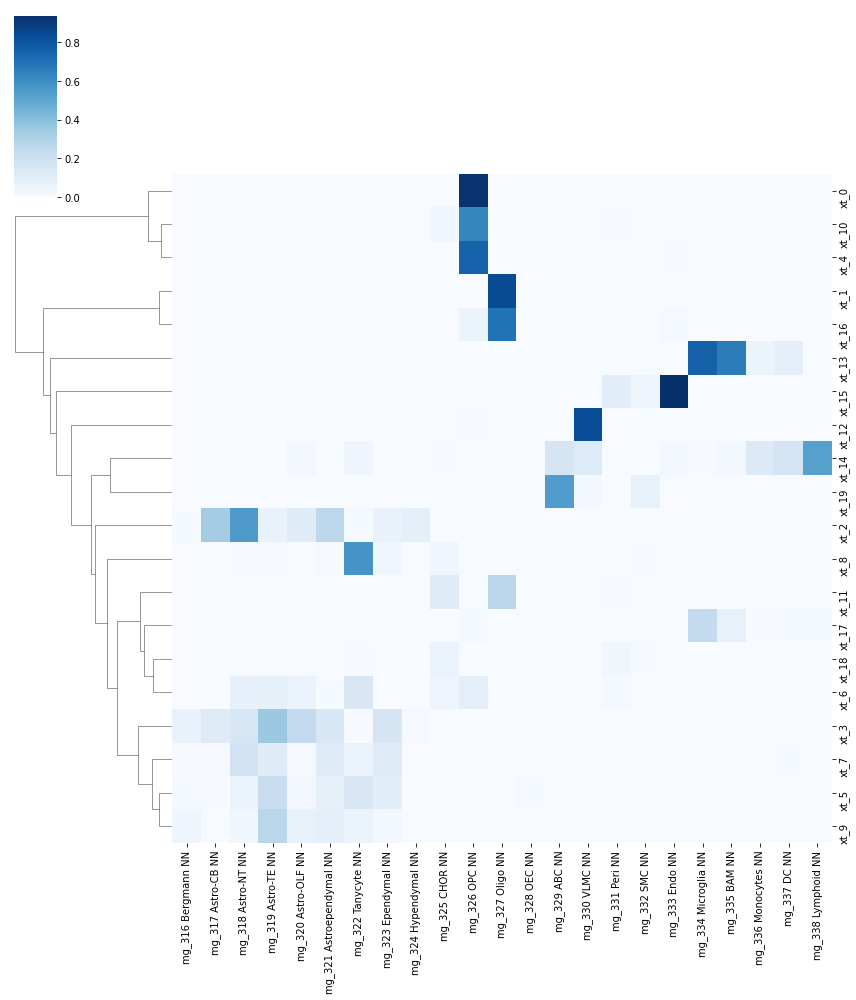

In [298]:
g = sns.clustermap(lim_MappingTable, col_cluster = False, method = 'ward', cmap = 'Blues',figsize = (12,14))
row_order = g.dendrogram_row.reordered_ind 

In [299]:
row_ord_plt = [int(i[3:]) for i in lim_MappingTable.index[row_order]]

In [ ]:
sc.pl.dotplot(sm.sams[org_two].adata, ['cj_GFAP','cj_MBP'], groupby = 'leiden_clusters', categories_order=row_ord_plt)

In [301]:
new_mapping

{'xt_0': '326 OPC NN',
 'xt_1': '327 Oligo NN',
 'xt_10': '326 OPC NN',
 'xt_11': '327 Oligo NN',
 'xt_12': '330 VLMC NN',
 'xt_13': '334 Microglia NN',
 'xt_14': '338 Lymphoid NN',
 'xt_15': '333 Endo NN',
 'xt_16': '327 Oligo NN',
 'xt_17': '334 Microglia NN',
 'xt_19': '329 ABC NN',
 'xt_2': '318 Astro-NT NN',
 'xt_3': '319 Astro-TE NN',
 'xt_4': '326 OPC NN',
 'xt_5': '319 Astro-TE NN',
 'xt_8': '322 Tanycyte NN',
 'xt_9': '319 Astro-TE NN'}

In [302]:
lim_MappingTable.columns

Index(['mg_316 Bergmann NN', 'mg_317 Astro-CB NN', 'mg_318 Astro-NT NN',
       'mg_319 Astro-TE NN', 'mg_320 Astro-OLF NN', 'mg_321 Astroependymal NN',
       'mg_322 Tanycyte NN', 'mg_323 Ependymal NN', 'mg_324 Hypendymal NN',
       'mg_325 CHOR NN', 'mg_326 OPC NN', 'mg_327 Oligo NN', 'mg_328 OEC NN',
       'mg_329 ABC NN', 'mg_330 VLMC NN', 'mg_331 Peri NN', 'mg_332 SMC NN',
       'mg_333 Endo NN', 'mg_334 Microglia NN', 'mg_335 BAM NN',
       'mg_336 Monocytes NN', 'mg_337 DC NN', 'mg_338 Lymphoid NN'],
      dtype='object')

In [304]:
lim_MappingTable.loc['xt_2',:]

mg_316 Bergmann NN          0.009457
mg_317 Astro-CB NN          0.336876
mg_318 Astro-NT NN          0.548464
mg_319 Astro-TE NN          0.067067
mg_320 Astro-OLF NN         0.114279
mg_321 Astroependymal NN    0.262132
mg_322 Tanycyte NN          0.014760
mg_323 Ependymal NN         0.067855
mg_324 Hypendymal NN        0.090989
mg_325 CHOR NN              0.000158
mg_326 OPC NN               0.000363
mg_327 Oligo NN             0.000000
mg_328 OEC NN               0.000000
mg_329 ABC NN               0.000000
mg_330 VLMC NN              0.000244
mg_331 Peri NN              0.000042
mg_332 SMC NN               0.000000
mg_333 Endo NN              0.000000
mg_334 Microglia NN         0.000000
mg_335 BAM NN               0.000000
mg_336 Monocytes NN         0.000000
mg_337 DC NN                0.000000
mg_338 Lymphoid NN          0.000000
Name: xt_2, dtype: float64

In [232]:
#Mapping CJ
grouped_mapping = {'316 Bergmann NN':'339 Astrocyte-like NN','317 Astro-CB NN':'339 Astrocyte-like NN','318 Astro-NT NN':'339 Astrocyte-like NN','319 Astro-TE NN':'339 Astrocyte-like NN','320 Astro-OLF NN':'339 Astrocyte-like NN',
                  '334 Microglia NN':'341 Macrophage NN', '335 BAM NN':'341 Macrophage NN',
                  '331 Peri NN':'340 Vascular NN','332 SMC NN':'340 Vascular NN','333 Endo NN':'340 Vascular NN'}
fin_mapping =[]
for item in sm.sams[org_two].adata.obs['leiden_clusters']:
    if org_two + '_' + str(item) not in new_mapping:
        fin_mapping.append('Unlabeled')
    else:
        if new_mapping[org_two + '_' + str(item)] not in grouped_mapping:
            fin_mapping.append(new_mapping[org_two + '_' + str(item)])
        else:
            fin_mapping.append(grouped_mapping[new_mapping[org_two + '_' + str(item)]])
fin_mapping = pd.Series(fin_mapping, index=sm.sams[org_two].adata.obs_names)

In [267]:
#Mapping AC
grouped_mapping = {'316 Bergmann NN':'339 Astrocyte-like NN','317 Astro-CB NN':'339 Astrocyte-like NN','318 Astro-NT NN':'339 Astrocyte-like NN','319 Astro-TE NN':'339 Astrocyte-like NN','320 Astro-OLF NN':'339 Astrocyte-like NN'}
fin_mapping =[]
for item in sm.sams[org_two].adata.obs['leiden_clusters']:
    if org_two + '_' + str(item) not in new_mapping:
        fin_mapping.append('Unlabeled')
    else:
        if new_mapping[org_two + '_' + str(item)] not in grouped_mapping:
            fin_mapping.append(new_mapping[org_two + '_' + str(item)])
        else:
            fin_mapping.append(grouped_mapping[new_mapping[org_two + '_' + str(item)]])
fin_mapping = pd.Series(fin_mapping, index=sm.sams[org_two].adata.obs_names)

In [305]:
#Mapping XT
grouped_mapping = {'316 Bergmann NN':'339 Astrocyte-like NN','317 Astro-CB NN':'339 Astrocyte-like NN','318 Astro-NT NN':'339 Astrocyte-like NN','319 Astro-TE NN':'339 Astrocyte-like NN','320 Astro-OLF NN':'339 Astrocyte-like NN',
                  '334 Microglia NN':'341 Macrophage NN', '335 BAM NN':'341 Macrophage NN'}
fin_mapping =[]
for item in sm.sams[org_two].adata.obs['leiden_clusters']:
    if org_two + '_' + str(item) not in new_mapping:
        fin_mapping.append('Unlabeled')
    else:
        if new_mapping[org_two + '_' + str(item)] not in grouped_mapping:
            fin_mapping.append(new_mapping[org_two + '_' + str(item)])
        else:
            fin_mapping.append(grouped_mapping[new_mapping[org_two + '_' + str(item)]])
fin_mapping = pd.Series(fin_mapping, index=sm.sams[org_two].adata.obs_names)

In [183]:
#Mapping DR
#Vascular does not include 333 endo because there is a cell type that clearly maps to endothelial cells.
grouped_mapping = {'316 Bergmann NN':'339 Astrocyte-like NN','317 Astro-CB NN':'339 Astrocyte-like NN','318 Astro-NT NN':'339 Astrocyte-like NN','319 Astro-TE NN':'339 Astrocyte-like NN','320 Astro-OLF NN':'339 Astrocyte-like NN',
                  '331 Peri NN':'340 Vascular NN','332 SMC NN':'340 Vascular NN'}
fin_mapping =[]
for item in sm.sams[org_two].adata.obs['leiden_clusters']:
    if org_two + '_' + str(item) not in new_mapping:
        fin_mapping.append('Unlabeled')
    else:
        if new_mapping[org_two + '_' + str(item)] not in grouped_mapping:
            fin_mapping.append(new_mapping[org_two + '_' + str(item)])
        else:
            fin_mapping.append(grouped_mapping[new_mapping[org_two + '_' + str(item)]])
fin_mapping = pd.Series(fin_mapping, index=sm.sams[org_two].adata.obs_names)

In [306]:
sm.sams[org_two].adata.obs['ss_subclass_v4_nounlabeled_nn'] = fin_mapping
sm.sams[org_two].adata.obs['leiden_clusters_nonneuron'] = sm.sams[org_two].adata.obs['leiden_clusters']

In [307]:
sam_NN.adata.obs['ss_subclass_v4_nounlabeled_nn'] = fin_mapping
sam_NN.adata.obs['leiden_clusters_nonneuron'] = sm.sams[org_two].adata.obs['leiden_clusters']

In [308]:
np.sort(sm.sams[org_two].adata.obs['ss_subclass_v4_nounlabeled_nn'].unique())

array(['322 Tanycyte NN', '326 OPC NN', '327 Oligo NN', '329 ABC NN',
       '330 VLMC NN', '333 Endo NN', '338 Lymphoid NN',
       '339 Astrocyte-like NN', '341 Macrophage NN', 'Unlabeled'],
      dtype=object)

In [309]:
np.sort(sam_NN.adata.obs['ss_subclass_v4_nounlabeled_nn'].unique())

array(['322 Tanycyte NN', '326 OPC NN', '327 Oligo NN', '329 ABC NN',
       '330 VLMC NN', '333 Endo NN', '338 Lymphoid NN',
       '339 Astrocyte-like NN', '341 Macrophage NN', 'Unlabeled'],
      dtype=object)

In [310]:
sm.sams[org_two].adata

AnnData object with n_obs × n_vars = 3166 × 19621
    obs: 'n_genes', 'n_counts', 'key', 'leiden_clusters', 'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac', 'eq_subclass_nounlabeled', 'eq_subclass_nounlabeled_NN', 'eq_subclass_nounlabeled_nnm', 'eq_subclass_nounlabeled_nmm', 'neurotransmitter', 'ss_subclass_nounlabeled', 'ss_subclass_v2_nounlabeled', 'ss_subclass_v3_nounlabeled', 'ss_subclass_nounlabeled_nmm', 'ss_subclass', 'ss_subclass_nounlabeled_nmm_micro', 'ss_subclass_nounlabeled_nmm_v2', 'ss_subclass_nounlabeled_nmm_v2_nn', 'ss_subclass_nounlabeled_nmm_v3_nn', 'neurotransmitter_v2', 'test', 'ss_subclass_old', 'ss_subclass_v4_nounlabeled', 'ss_subclass_v4_nounlabeled_nn', 'leiden_clusters_nonneuron'
    var: 'mask_genes', 'means', 'variances', 'weights', 'spatial_dispersions', 'mean_correction'
    uns: 'dimred_indices', 'path_to_file', 'preprocess_args', 'ranked_genes', 'run_args'
    obsm: 'Raw_X', 'X_pca', 'X_processed', 'X_umap', 'X_umap_samap'
    varm: 'PCs', 'PCs_SAMap

In [311]:
sam_NN.adata

AnnData object with n_obs × n_vars = 3166 × 19621
    obs: 'n_genes', 'n_counts', 'key', 'leiden_clusters', 'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac', 'eq_subclass_nounlabeled', 'eq_subclass_nounlabeled_NN', 'eq_subclass_nounlabeled_nnm', 'eq_subclass_nounlabeled_nmm', 'neurotransmitter', 'ss_subclass_nounlabeled', 'ss_subclass_v2_nounlabeled', 'ss_subclass_v3_nounlabeled', 'ss_subclass_nounlabeled_nmm', 'ss_subclass', 'ss_subclass_nounlabeled_nmm_micro', 'ss_subclass_nounlabeled_nmm_v2', 'ss_subclass_nounlabeled_nmm_v2_nn', 'ss_subclass_nounlabeled_nmm_v3_nn', 'neurotransmitter_v2', 'test', 'ss_subclass_old', 'ss_subclass_v4_nounlabeled', 'ss_subclass_v4_nounlabeled_nn', 'leiden_clusters_nonneuron'
    var: 'mask_genes', 'means', 'variances', 'weights', 'spatial_dispersions'
    uns: 'dimred_indices', 'path_to_file', 'preprocess_args', 'ranked_genes', 'run_args'
    obsm: 'Raw_X', 'X_pca', 'X_processed', 'X_umap'
    varm: 'PCs'
    layers: 'X_disp'
    obsp: 'connectivities

In [312]:
fin_labels = []
for item in sam.adata.obs_names:
    if item in sm.sams[org_two].adata.obs_names:
        fin_labels.append(sm.sams[org_two].adata.obs.loc[item,'ss_subclass_v4_nounlabeled_nn'])
    else:
        fin_labels.append(sam.adata.obs.loc[item,'ss_subclass_v4_nounlabeled'])
fin_labels = pd.Series(fin_labels, index=sam.adata.obs_names)
sam.adata.obs['ss_subclass_v4_nounlabeled_nn'] = fin_labels

In [313]:
np.sort(sam.adata.obs['ss_subclass_v4_nounlabeled_nn'].unique())

array(['009 L2/3 IT PIR-ENTl Glut', '011 L2 IT ENT-po Glut',
       '041 OB-in Frmd7 Gaba', '054 STR Prox1 Lhx6 Gaba',
       '056 Sst Chodl Gaba', '057 NDB-SI-MA-STRv Lhx8 Gaba',
       '058 PAL-STR Gaba-Chol', '064 STR-PAL Chst9 Gaba',
       '068 LSX Otx2 Gaba', '070 LSX Prdm12 Slit2 Gaba',
       '072 LSX Sall3 Lmo1 Gaba', '073 MEA-BST Sox6 Gaba',
       '074 MEA-BST Lhx6 Sp9 Gaba', '079 CEA-BST Six3 Cyp26b1 Gaba',
       '082 CEA-BST Ebf1 Pdyn Gaba', '085 SI-MPO-LPO Lhx8 Gaba',
       '086 MPO-ADP Lhx8 Gaba', '088 BST Tac2 Gaba',
       '090 BST-MPN Six3 Nrgn Gaba', '091 ARH-PVi Six6 Dopa-Gaba',
       '092 TMv-PMv Tbx3 Hist-Gaba', '093 RT-ZI Gnb3 Gaba',
       '094 SCH Six6 Cdc14a Gaba', '097 PVHd-SBPV Six3 Prox1 Gaba',
       '098 AHN-SBPV-PVHd Pdrm12 Gaba', '100 AHN Onecut3 Gaba',
       '101 ZI Pax6 Gaba', '102 DMH-LHA Gsx1 Gaba',
       '103 PVHd-DMH Lhx6 Gaba', '104 TU-ARH Otp Six6 Gaba',
       '105 TMd-DMH Foxd2 Gaba', '106 PVpo-VMPO-MPN Hmx2 Gaba',
       '107 DMH Hmx2 Ga

In [314]:
sam.adata

AnnData object with n_obs × n_vars = 42221 × 19621
    obs: 'n_genes', 'n_counts', 'key', 'leiden_clusters', 'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac', 'eq_subclass_nounlabeled', 'eq_subclass_nounlabeled_NN', 'eq_subclass_nounlabeled_nnm', 'eq_subclass_nounlabeled_nmm', 'neurotransmitter', 'ss_subclass_nounlabeled', 'ss_subclass_v2_nounlabeled', 'ss_subclass_v3_nounlabeled', 'ss_subclass_nounlabeled_nmm', 'ss_subclass', 'ss_subclass_nounlabeled_nmm_micro', 'ss_subclass_nounlabeled_nmm_v2', 'ss_subclass_nounlabeled_nmm_v2_nn', 'ss_subclass_nounlabeled_nmm_v3_nn', 'neurotransmitter_v2', 'test', 'ss_subclass_old', 'ss_subclass_v4_nounlabeled', 'ss_subclass_v4_nounlabeled_nn'
    var: 'mask_genes', 'means', 'variances', 'weights', 'spatial_dispersions'
    uns: 'dimred_indices', 'path_to_file', 'preprocess_args', 'ranked_genes', 'run_args'
    obsm: 'Raw_X', 'X_pca', 'X_processed', 'X_umap'
    varm: 'PCs'
    layers: 'X_disp'
    obsp: 'connectivities', 'distances', 'nnm'

In [315]:
set(sam.adata.obs['ss_subclass_v4_nounlabeled'].unique()) - set(sam.adata.obs['ss_subclass_v4_nounlabeled_nn'].unique())

{'xt_22', 'xt_39', 'xt_4'}

In [316]:
print(fn,fn_NN)

Active_SAM_joined/SAM_XT_joined_Slc17a6_cleaned_03122205.h5ad Active_SAM_joined/SAM_XT_nonneural_cleaned_07212026.h5ad


In [317]:
print(sam_NN.adata.obs['ss_subclass_v4_nounlabeled_nn'].isna().sum())

0


In [318]:
print(sm.sams[org_two].adata.obs['ss_subclass_v4_nounlabeled_nn'].isna().sum())

0


In [319]:
print(sam.adata.obs['ss_subclass_v4_nounlabeled_nn'].isna().sum())

0


In [ ]:
save_samap(sm,'Active_SAMap_Joined/sm_hypo_nonneural_07222026.pkl')

In [ ]:
sam.save_anndata(fn)

In [ ]:
sam_NN.save_anndata(fn_NN)